In [3]:
import h5py
import scipy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
import re 
import cooltools
import cooler
# import cooltools.lib.plotting
from cooltools import numutils
from itertools import cycle, islice

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

from scipy import ndimage as nd
from scipy.stats import pearsonr
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import pearsonr
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
from concurrent.futures import ProcessPoolExecutor, as_completed

In [4]:
from matplotlib.colors import LinearSegmentedColormap
colors = ["white", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_to_red", colors)

In [5]:
# HiC basics metrices
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
# plt.style.use('seaborn-poster')

# import open2c libraries
import bioframe
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [6]:
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

In [8]:
from itertools import repeat
def moving_average(data, window_size):
    cumsum_vec = np.cumsum(np.insert(data, 0, 0)) 
    return (cumsum_vec[window_size:] - cumsum_vec[:-window_size]) / window_size

def moving_average_same_length(data, window_size):
    if window_size % 2 == 0:
        raise ValueError("Window size should be odd")
    pad_size = window_size // 2
    padded_data = np.pad(data, (pad_size, pad_size), 'edge')
    # Compute moving average using a convolution approach
    window = np.ones(int(window_size))/float(window_size)
    smoothed_data = np.convolve(padded_data, window, 'valid')
    return smoothed_data

In [9]:
chrom_size_path = '/projects/ps-renlab2/y2xie/projects/genome_ref/hg38.main.chrom.sizes'
chrom_sizes = pd.read_csv(chrom_size_path, sep='\t', header=None, index_col=0)
nbins = np.floor(np.log2(chrom_sizes[1].values.max() / 2500) / 0.125)
bins = 2500 * np.exp2(0.125 * np.arange(nbins+1))

In [ ]:
hmeta = pd.read_csv("integration/FNIH_DHC_genescore_prediction.metadata.csv", index_col=0)
np.unique(hmeta['predicted.id'], return_counts=True)

## Celltype sepcfic structures

In [21]:
### 25kb matrices
binpass = np.load('../04.matrices/FNIH_heart_dhc_binfilter.npy', allow_pickle = True)
comp = pd.read_csv('../04.matrices/comp/FNIH_heart_dhc_celltype_comp.impute.allbin.txt', sep ='\t', index_col=0)
comp[['chrom', 'start', 'end']] = comp.index.to_series().str.split('-', expand=True)

bbulk_ins = pd.read_csv("../impute/25K/domain/pseudobulk/FNIH_Heart_pseudobulk.insulation.csv", index_col=0)

In [42]:
### Check some cell types
korder = ['vCM', 'Lymphoid', 'Fibroblast', 'Endothelial', 'Myeloid']

### Check some regions
rlist = [['chr17', 67_750_000, 68_775_000],
         ['chr6', 147_700_000, 148_725_000],
         ['chr10', 17_450_000, 18_475_000],
         ['chr10', 119_300_000, 120_300_000],
         ['chr15', 47_500_000, 49_500_000],
         ['chr11', 59_000_000, 61_000_000], 
         ['chr2', 117_500_000, 119_500_000]]

# TTN: chr2, 178_000_000, 180_000_000
# TBX5: chr12, 113_000_000, 115_000_000
# FBN1: chr15, 47_500_000, 49_500_000
# COL4A4: chr2, 226_500_000, 228_500_000
# VEGFC: chr4, 175_500_000, 177_500_000

# cell type bound1: 'chr10', 17_000_000, 19_000_000
# cell type bound2: 'chr2', 154_000_000, 156_000_000

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 33 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'E', 'F', 'L', 'M', 'a', 'b', 'd', 'e', 'eight', 'four', 'h', 'i', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'six', 'space', 't', 'three', 'two', 'v', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 25, 27, 38, 40, 41, 47, 48, 68, 69, 71, 72, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 89, 92, 3228]
INFO:fontTools.subset:Closed glyph list over 'MATH': 33 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'E', '

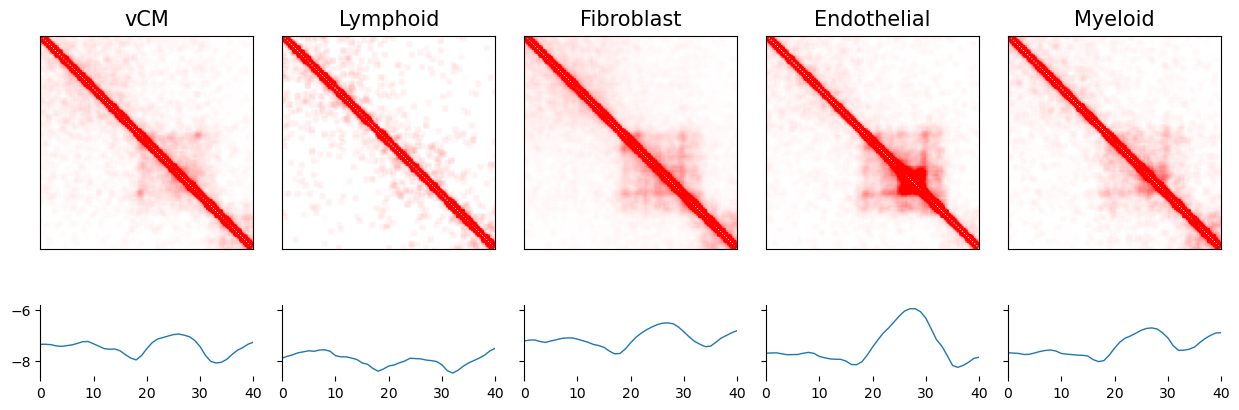

In [44]:
ipath = '../04.matrices/impute/cool/'
fig, axes = plt.subplots(2, len(korder), figsize=(2.5*len(korder),5), 
                         gridspec_kw={'height_ratios':[3, 0.5]}, sharey='row')
#                          gridspec_kw={'height_ratios':[3, 0.5, 0.5]}, sharey='row')

for ind, ct in enumerate(korder):
    i = 1
    chrom = rlist[i][0]
    res = 25_000
    res2 = 100_000
    l, r = rlist[i][1], rlist[i][2]

    ll = l//res
    rr = r//res
    ll2 = l//res2
    rr2 = r//res2
    boundl = chrom + "-" + str(l) + "-" + str(l+res)
    boundr = chrom + "-" + str(r-res) + "-" + str(r)

    cool = cooler.Cooler(f'{ipath}/{ct}_10kb.cool::/')
    Q = cool.matrix(balance=False, sparse=True).fetch((chrom, l, r)).toarray()
    Q = Q - np.diag(np.diag(Q))
    
    ax = axes[0, ind]
    vv = 0.002
    im = ax.imshow(Q, cmap = custom_cmap, vmax = vv)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(ct, fontsize = 15, y = 1.01)
    
    ax = axes[1, ind]
    sns.despine(bottom=True, ax=ax)
    ax.plot(np.arange(rr - ll), np.log2(bbulk_ins.loc[boundl:boundr][ct]), linewidth=1)
    ax.set_xlim(0, rr - ll -1) ### 25kb

plt.tight_layout()
plt.savefig(f'plot/FIG_5celltypes_{chrom}_{ll}_{rr}_impute_res10k_ins_comp.pdf', transparent = True)

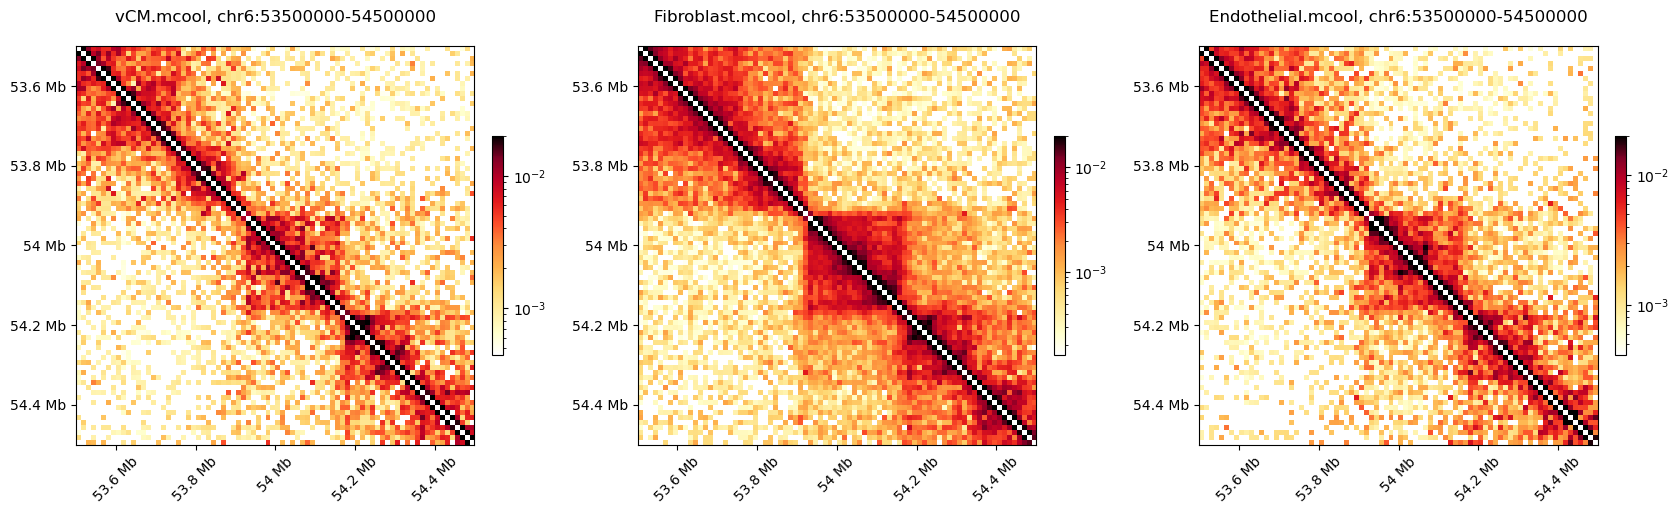

In [132]:
ipath = "../04.matrices/raw/cool/"
res = 25_000
scale = 0.02

chrom = 'chr15'
res = 25_000
res2 = 100_000
l, r = 47_500_000, 49_500_000
region = (chrom, l, r)
    
f, axes = plt.subplots(1, 3, figsize=(17, 5))
for idx, sample in enumerate(['vCM.mcool', 'Fibroblast.mcool', 'Endothelial.mcool']): ### similar cell number
    clr = cooler.Cooler(ipath + sample + f'::resolutions/{res}')
    mtx = clr.matrix(balance='weight').fetch(region)
    mtx = mtx - np.diag(np.diag(mtx))
    ax = axes[idx]
    im = ax.matshow(mtx, cmap="fall", norm=LogNorm(vmax = scale), 
                    #extent=(0, clr.chromsizes[chromp], clr.chromsizes[chromp], 0))
                    extent=(start, end, end, start))
    format_ticks(ax)
    ax.set_title(sample + ", " + chromp + ":" + str(start) + "-" + str(end), y=1.04)
    plt.colorbar(im, fraction=0.025, pad=0.04, ax = ax)

plt.tight_layout()

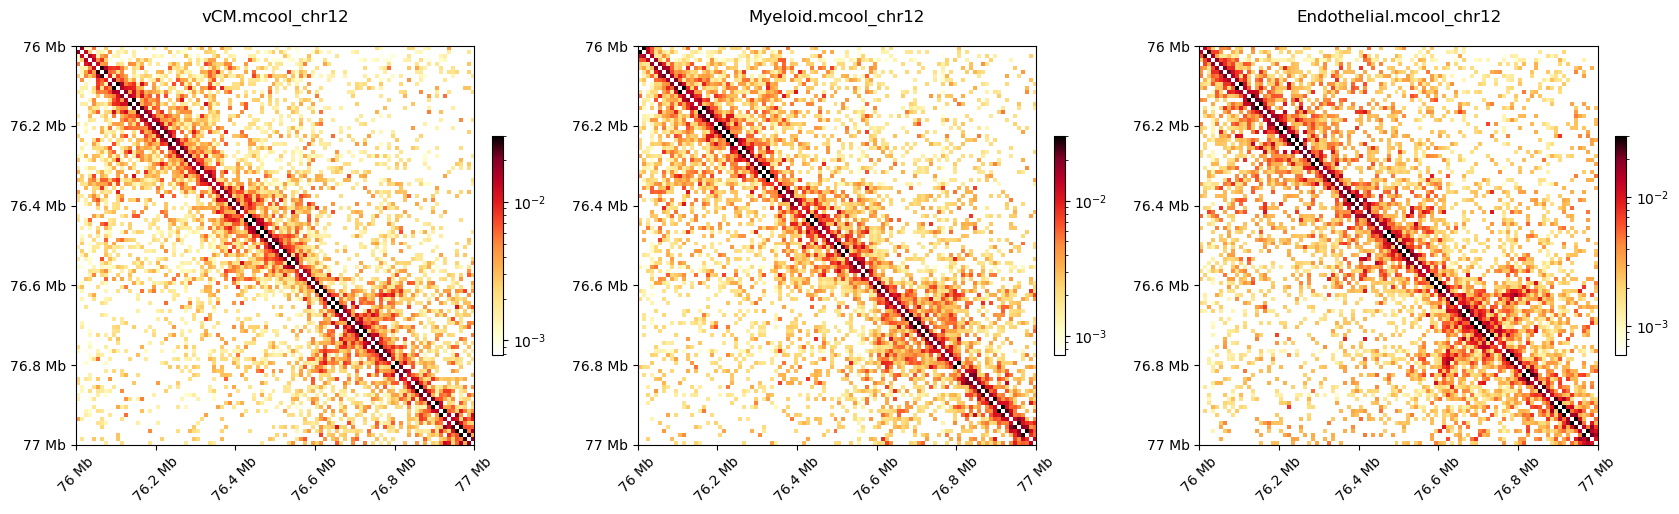

In [27]:
chromp = ('chr12')
start, end = 76_000_000, 77_000_000
region = (chromp, start, end)
res = 10_000
scale = 0.03

f, axes = plt.subplots(1, 3, figsize=(17, 5))

for idx, sample in enumerate(['vCM.mcool', 'Myeloid.mcool', 'Endothelial.mcool']): ### similar cell number
    clr = cooler.Cooler("../04.matrices/raw/cool/" + sample + f'::resolutions/{res}')
    mtx = clr.matrix(balance='weight').fetch(region)
    mtx = mtx - np.diag(np.diag(mtx))
    ax = axes[idx]
    im = ax.matshow(mtx, cmap="fall", norm=LogNorm(vmax = scale), 
                    #extent=(0, clr.chromsizes[chromp], clr.chromsizes[chromp], 0))
                    extent=(start, end, end, start))
    format_ticks(ax)
    ax.set_title(sample + "_" + chromp, y=1.04)
    plt.colorbar(im, fraction=0.025, pad=0.04, ax = ax)

plt.tight_layout()

## Visualize by HF states

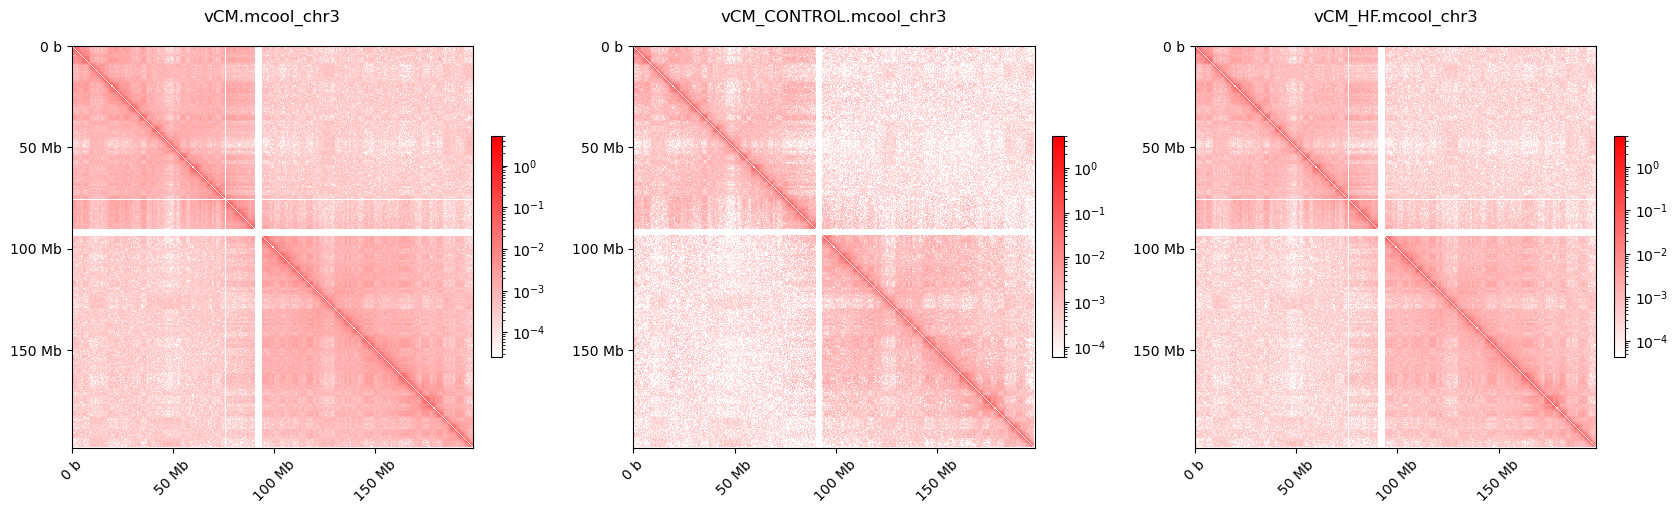

In [10]:
ct = 'vCM'
res = 500_000
scale = 5

ipath = "/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925//04.matrices/raw/cool/"
chromp = ('chr3')
f, axes = plt.subplots(1, 3, figsize=(17, 5))

for idx, sample in enumerate([f'{ct}.mcool', f'{ct}_CONTROL.mcool', f'{ct}_HF.mcool']): 
    clr = cooler.Cooler(ipath + sample + f'::resolutions/{res}')
    mtx = clr.matrix(balance="weight").fetch(chromp)
    mtx = mtx - np.diag(np.diag(mtx))
    ax = axes[idx]
    im = ax.matshow(mtx, cmap = custom_cmap, norm=LogNorm(vmax = scale), 
                    extent=(0, clr.chromsizes[chromp], clr.chromsizes[chromp], 0))
                    #extent=(start, end, end, start))
    format_ticks(ax)
    ax.set_title(sample + "_" + chromp, y=1.04)
    plt.colorbar(im, fraction=0.025, pad=0.04, ax = ax)

plt.tight_layout()

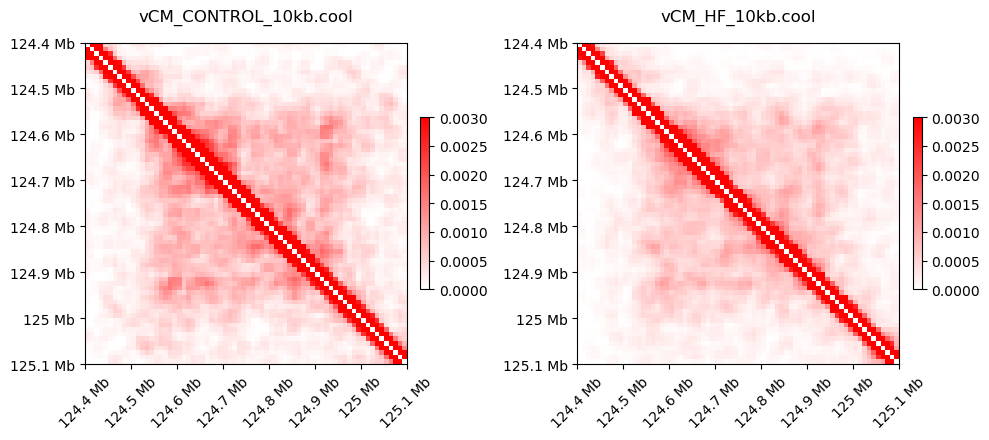

In [23]:
### Also output impute map
f = 'vCM'
chromp = ('chr8')
start, end = 124_400_000, 125_100_000  
region = (chromp, start, end)

ipath2 = "/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925//04.matrices/impute/cool/"
ct1 = f'{f}_CONTROL'
ct2 = f'{f}_HF'
ress = '10kb'
scale = 0.003

f, axes = plt.subplots(1, 2, figsize=(10, 5))
for idx, sample in enumerate([f'{ct1}_{ress}.cool', f'{ct2}_{ress}.cool']): 
    clr = cooler.Cooler(ipath2 + sample + '::/')
    mtx = clr.matrix(balance=False).fetch(region)
    mtx = mtx - np.diag(np.diag(mtx))
    ax = axes[idx]
    im = ax.matshow(mtx, cmap = custom_cmap, vmax = scale, vmin = 0, 
                    extent=(start, end, end, start))
    format_ticks(ax)
    ax.set_title(sample, y=1.04)
    plt.colorbar(im, fraction=0.025, pad=0.04, ax = ax)
    
plt.tight_layout()
# plt.savefig(f"plot/FIG_{ct1}_{ct2}_{chromp}_{start}_{end}_res{res}_impute.pdf")

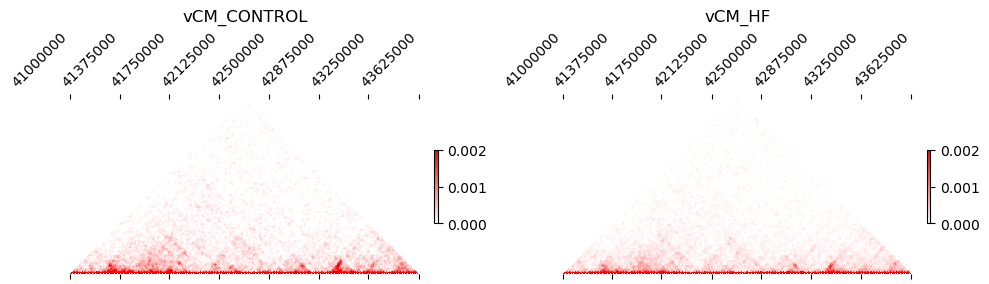

In [30]:
### Also output impute map
f = 'vCM'
ipath2 = "/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925//04.matrices/impute/cool/"
ct1 = f'{f}_CONTROL'
ct2 = f'{f}_HF'
ress = '10kb'
scale = 0.002

clr1 = cooler.Cooler(ipath2 + f'{ct1}_{ress}.cool::/')
clr2 = cooler.Cooler(ipath2 + f'{ct2}_{ress}.cool::/')

Q = clr1.matrix(balance=False).fetch(region)
upper_tri = Q - np.diag(np.diag(Q)) 

Q = clr2.matrix(balance=False).fetch(region)
lower_tri = Q - np.diag(np.diag(Q)) 

f, axes = plt.subplots(1, 2, figsize=(10, 5))

Qrotate = nd.rotate(upper_tri, 45, order=0, reshape=True, prefilter=False, cval=0)
ax = axes[0]
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
im = ax.matshow(Qrotate, cmap=custom_cmap, vmax = scale, vmin = 0)
h = len(Qrotate)
ax.set_ylim([0.5*h, 0])
ax.set_xlim([0, h])
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_title(ct1)

num_labels = 8  # Specify the number of labels
x_positions = np.linspace(0, Qrotate.shape[1] - 1, num_labels, dtype=int)
pos_list_new = range(start, end, int((end-start)/num_labels))
ax.set_xticks(x_positions)
ax.set_xticklabels(pos_list_new, rotation=45, ha="right")  # Rotate x-axis labels
plt.colorbar(im, ax=ax, fraction=0.01, pad=0.04)

Qrotate = nd.rotate(lower_tri, 45, order=0, reshape=True, prefilter=False, cval=0)
ax = axes[1]
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
im = ax.matshow(Qrotate, cmap=custom_cmap, vmax = scale, vmin = 0)
h = len(Qrotate)
ax.set_ylim([0.5*h, 0])
ax.set_xlim([0, h])
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_title(ct2)

ax.set_xticks(x_positions)
ax.set_xticklabels(pos_list_new, rotation=45, ha="right")  # Rotate x-axis labels
plt.colorbar(im, ax=ax, fraction=0.01, pad=0.04)

plt.tight_layout()

# plt.savefig(f"plot/FIG_{ct1}_{ct2}_{chromp}_{start}_{end}_res{res}_impute.pdf")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 27 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'F', 'H', 'L', 'M', 'N', 'O', 'R', 'T', 'eight', 'five', 'hyphen', 'minus', 'nine', 'nonmarkingreturn', 'one', 'period', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'v', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 24, 25, 26, 27, 28, 38, 41, 43, 47, 48, 49, 50, 53, 55, 66, 89, 3228]
INFO:fontTools.subset:Closed glyph list over 'MATH': 27 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'F', 'H', 'L', 'M', 'N', 'O', 'R',

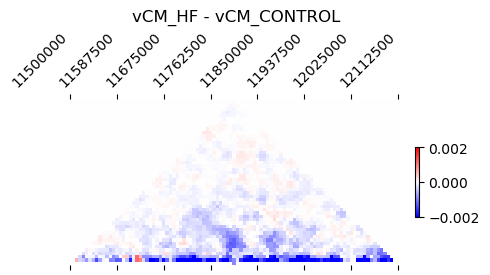

In [48]:
### Plot substrated map
scale = 0.002
clr1 = cooler.Cooler(ipath2 + f'{ct1}_{ress}.cool::/')
clr2 = cooler.Cooler(ipath2 + f'{ct2}_{ress}.cool::/')

Q = clr1.matrix(balance=False).fetch(region)
upper_tri = Q - np.diag(np.diag(Q)) 

Q = clr2.matrix(balance=False).fetch(region)
lower_tri = Q - np.diag(np.diag(Q)) 

f, ax = plt.subplots(figsize=(5, 5))

Qrotate = nd.rotate((lower_tri - upper_tri), 45, order=0, reshape=True, prefilter=False, cval=0)
# Qrotate = (Qrotate1+1)/(Qrotate2+1)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
im = ax.matshow(Qrotate, cmap='bwr', vmax = scale, vmin = -scale)
h = len(Qrotate)
ax.set_ylim([0.5*h, 0])
ax.set_xlim([0, h])
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_title(f'{ct2} - {ct1}')

# pos_list_new = range(0, int((end - start)/res), 10)
# new_pos_list = [round(np.sqrt(2)*ii) for ii in pos_list_new]
# ax.set_xticks(new_pos_list)
# plt.colorbar(im, ax=ax, fraction=0.01, pad=0.04)

num_labels = 8  # Specify the number of labels
x_positions = np.linspace(0, Qrotate.shape[1] - 1, num_labels, dtype=int)
pos_list_new = range(start, end, int((end-start)/num_labels))
ax.set_xticks(x_positions)
ax.set_xticklabels(pos_list_new, rotation=45, ha="right")  # Rotate x-axis labels
plt.colorbar(im, ax=ax, fraction=0.01, pad=0.04)

plt.tight_layout()
plt.savefig(f"plot/FIG_{ct1}_{ct2}_{chromp}_{start}_{end}_res{res}_impute_substract.pdf")